# Elbow Method

The Elbow Method is a technique used to help determine the optimal number of clusters (`K`) in K-Means clustering.

K-Means requires us to specify the number of clusters beforehand:

```python
KMeans(n_clusters=K)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = df[features]

X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [6]:
inertia = []

k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

In [7]:
for k, value in zip(
    k_values,
    inertia
):

    print(
        f"K = {k} → "
        f"Inertia = {value:.2f}"
    )

K = 1 → Inertia = 600.00
K = 2 → Inertia = 222.36
K = 3 → Inertia = 139.82
K = 4 → Inertia = 114.09
K = 5 → Inertia = 90.93
K = 6 → Inertia = 81.54
K = 7 → Inertia = 72.63
K = 8 → Inertia = 62.54
K = 9 → Inertia = 55.12
K = 10 → Inertia = 47.39


In [8]:
elbow_df = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": inertia
})

elbow_df

,Number of Clusters,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


In [9]:
elbow_df = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": inertia
})

elbow_df

,Number of Clusters,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


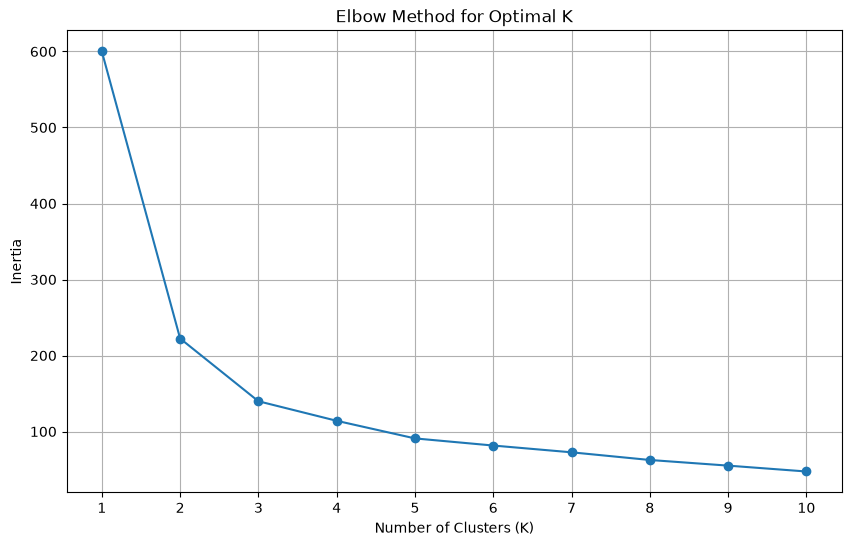

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal K"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.xticks(
    list(k_values)
)

plt.grid()

plt.show()